# Model Comparison

Now that we have all of these different models, we need to compare their performance

In [1]:
import sys

sys.path.append("..")

from src.data.load_data import load_all_data

ratings, movies, users = load_all_data()

In [3]:
from src.data.split import train_test_split_by_user

train_df, test_df = train_test_split_by_user(ratings, test_size=0.2)

set(train_df.index).intersection(set(test_df.index))

user = ratings["user_id"].iloc[0]

train_user = train_df[train_df["user_id"] == user]
test_user = test_df[test_df["user_id"] == user]

In [4]:
import pandas as pd

from src.evaluation.evaluate import evaluate_model
from src.features.content import build_genre_matrix
from src.models.popularity import PopularityRecommender
from src.models.content import ContentRecommender
from src.models.item_collaborative import ItemCollaborativeRecommender
from src.models.hybrid import HybridRecommender

genre_matrix = build_genre_matrix(movies)

models = {
    "popularity_bayesian": PopularityRecommender(method="bayesian").fit(train_df),
    "content_based": ContentRecommender().fit(movies, genre_matrix),
    "item_collaborative": ItemCollaborativeRecommender(min_rating=4).fit(train_df),
    "hybrid": HybridRecommender(
        popularity_model=PopularityRecommender(method="bayesian"),
        content_model=ContentRecommender(),
        collaborative_model=ItemCollaborativeRecommender(min_rating=4),
        weights={
            "popularity": 0.15,
            "content": 0.25,
            "collaborative": 0.60,
        },
    ).fit(train_df, movies, genre_matrix),
}

results = []

for name, model in models.items():
    metrics = evaluate_model(model, train_df, test_df, k=10)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[
    ["model", "precision_at_k", "recall_at_k", "ndcg_at_k"]
]

results_df.sort_values("ndcg_at_k", ascending=False)

,model,precision_at_k,recall_at_k,ndcg_at_k
2,item_collaborative,0.131871,0.064133,0.147047
3,hybrid,0.128477,0.061890,0.141710
0,popularity_bayesian,0.054404,0.019753,0.058728
1,content_based,0.035546,0.017031,0.037486


<Axes: xlabel='model'>

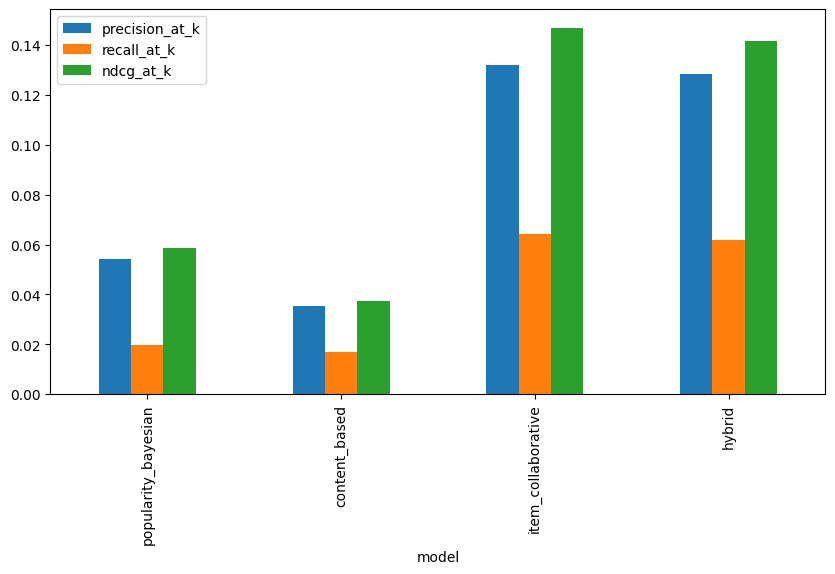

In [5]:
results_df.plot(
    x="model",
    y=["precision_at_k", "recall_at_k", "ndcg_at_k"],
    kind="bar",
    figsize=(10, 5),
)

Collaborative filtering achieved the best performance due to its ability to leverage user interaction patterns, while content-based methods underperformed due to limited feature richness. A hybrid model was implemented, though initial linear weighting slightly degraded performance, highlighting the importance of proper signal balancing.

I want to try and improve the current performance of the hybird model as it is currently linear and naive.

In [6]:
from src.evaluation.tuning import tune_hybrid_weights

hybrid_tuning_results = tune_hybrid_weights(
    train_df=train_df,
    test_df=test_df,
    movies=movies,
    genre_matrix=genre_matrix,
    k=10,
    sample_users=500,
)

hybrid_tuning_results

,precision_at_k,recall_at_k,ndcg_at_k,num_users_evaluated,model,popularity_weight,content_weight,collaborative_weight
0,0.1276,0.063423,0.142404,500,collab_90,0.05,0.05,0.90
1,0.1270,0.062917,0.141944,500,collab_85,0.05,0.10,0.85
2,0.1258,0.062346,0.140822,500,collab_80,0.10,0.10,0.80
3,0.1258,0.062077,0.140571,500,collab_75,0.10,0.15,0.75
4,0.1254,0.062329,0.139445,500,collab_70,0.15,0.15,0.70
5,0.0996,0.046962,0.111655,500,balanced,0.33,0.33,0.34


Hybrid models were evaluated with varying weight configurations, showing that collaborative filtering contributed the majority of predictive power. Additional signals such as content-based features and popularity provided marginal improvements but did not outperform behavior-based recommendations due to limited feature richness.

# Cold start model

For this application, it will be very important to have some sort of system to deal with cold start. This means when there is a new user who has not rated any movies, there needs to be a system in place to still give them movie recommendations

In [ ]:
from src.models.cold_start_hybrid import ColdStartHybridRecommender
from src.models.hybrid import HybridRecommender
from src.models.popularity import PopularityRecommender
from src.models.content import ContentRecommender
from src.models.item_collaborative import ItemCollaborativeRecommender

cold_start_model = ColdStartHybridRecommender(
    hybrid_model=HybridRecommender(
        popularity_model=PopularityRecommender(method="bayesian"),
        content_model=ContentRecommender(),
        collaborative_model=ItemCollaborativeRecommender(min_rating=4),
        weights={
            "popularity": 0.05,
            "content": 0.05,
            "collaborative": 0.90,
        },
    ),
    content_model=ContentRecommender(),
    popularity_model=PopularityRecommender(method="bayesian"),
    min_user_ratings=10,
)

cold_start_model.fit(train_df, movies, genre_matrix)

recs = cold_start_model.recommend(user_id=1, ratings=train_df, k=10)
recs.merge(movies, on="movie_id")[["title", "score"]]